# Hands-on: Von Schwingungssignalen zu Merkmalen und Anomalien

**Ziel der Session:** Wir bauen Schritt für Schritt eine kleine Analyse-Pipeline:

1. Zeitreihe → Spektrum (FFT)
2. Zeitinformation zurückholen → STFT / Spektrogramm
3. Spektren in wenige interpretierbare Merkmale verdichten
4. Viele Messungen pro Bauteil zusammenfassen
5. Abweichungen über Distanzen zum Referenzspektrum erkennen
6. Optional: einfache Cluster-Analyse und Drehzahl-Normalisierung

> Die Daten sind synthetisch, damit wir die Grundwahrheit kennen. Erst am Ende schauen wir, ob unsere Merkmale die eingebauten Unterschiede sichtbar machen.

**Pakete:** `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn`

## 0. Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True

## 1. Synthetische Bauteile und Messungen

Jedes Bauteil wird mehrfach gemessen. Es gibt drei Zustände:

- **normal:** Grundkomponenten bei ca. 120, 360 und 720 Hz
- **Typ A:** zusätzliche Energie um ca. 1100 Hz
- **Typ B:** verschobene mittlere Frequenzkomponente + impulsive Ereignisse

Die Labels benutzen wir nur zur späteren Kontrolle.

In [7]:
FS = 4000
DURATION = 1.0
N = int(FS * DURATION)
T = np.arange(N) / FS

N_PARTS_PER_GROUP = 10
N_MEASUREMENTS = 12

def simulate_measurement(condition="normal", rng=None):
    if rng is None:
        rng = np.random.default_rng()

    f1 = 120 + rng.normal(0, 2)
    f2 = 360 + rng.normal(0, 3)
    f3 = 720 + rng.normal(0, 5)

    a1 = 1.0 + rng.normal(0, 0.08)
    a2 = 0.65 + rng.normal(0, 0.06)
    a3 = 0.35 + rng.normal(0, 0.05)

    p1, p2, p3 = rng.uniform(0, 2*np.pi, 3)
    x = (
        a1 * np.sin(2*np.pi*f1*T + p1)
        + a2 * np.sin(2*np.pi*f2*T + p2)
        + a3 * np.sin(2*np.pi*f3*T + p3)
    )
    x += 0.22 * rng.standard_normal(N)

    if condition == "Typ A":
        f_fault = 1100 + rng.normal(0, 10)
        x += 0.55 * np.sin(2*np.pi*f_fault*T + rng.uniform(0, 2*np.pi))

    elif condition == "Typ B":
        # neue dominante Komponente um 430 Hz
        x += 0.55 * np.sin(2*np.pi*(430 + rng.normal(0, 5))*T + rng.uniform(0, 2*np.pi))
        for _ in range(rng.integers(2, 5)):
            center = rng.integers(100, N-100)
            width = rng.integers(5, 18)
            pulse = signal.windows.gaussian(2*width+1, std=max(width/4, 1))
            x[center-width:center+width+1] += rng.uniform(2.5, 4.5) * pulse

    return x

records, signals = [], {}
part_id = 0

for condition in ["normal", "Typ A", "Typ B"]:
    for _ in range(N_PARTS_PER_GROUP):
        part_id += 1
        rpm = 1800 + rng.normal(0, 70)
        for measurement in range(N_MEASUREMENTS):
            signals[(part_id, measurement)] = simulate_measurement(condition, rng)
            records.append({
                "part_id": part_id,
                "measurement": measurement,
                "condition": condition,
                "rpm": rpm
            })

meta = pd.DataFrame(records)
print(f"{meta['part_id'].nunique()} Bauteile, {len(meta)} Einzelmessungen")
meta.head()

30 Bauteile, 360 Einzelmessungen


,part_id,measurement,condition,rpm
0,1,0,normal,1821.330196
1,1,1,normal,1821.330196
2,1,2,normal,1821.330196
3,1,3,normal,1821.330196
4,1,4,normal,1821.330196


## 2. Zeitreihe → Spektrum

Für $\(N\)$ Samples bei Abtastrate \(f_s\):

\[
\Delta f = \frac{f_s}{N} = \frac{1}{T_\mathrm{obs}}
\]

Nyquist-Frequenz:

\[
f_\mathrm{Nyquist} = \frac{f_s}{2}
\]

Für reale Signale reicht meist das einseitige Spektrum.

Abtastrate: 4000 Hz
Messdauer: 1.0 s
Nyquist: 2000.0 Hz
Frequenzauflösung: 1.00 Hz


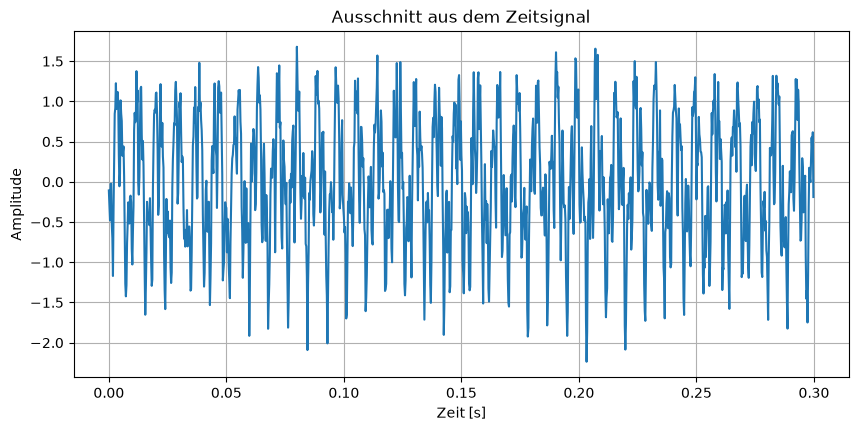

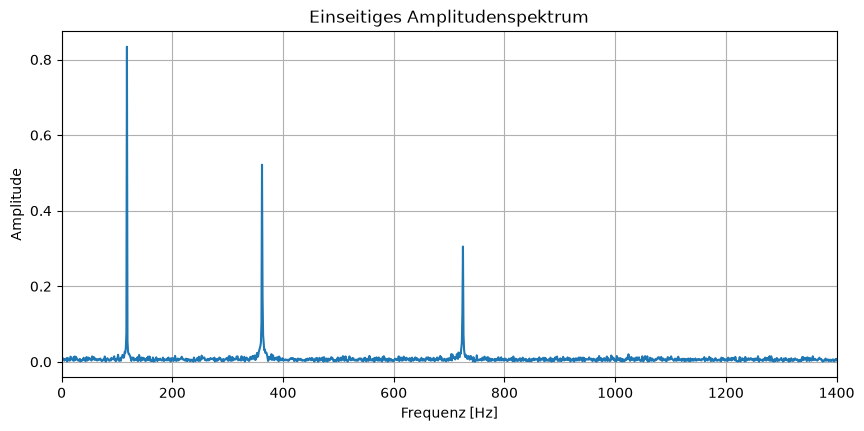

In [8]:
x = signals[(1, 0)]
freqs = np.fft.rfftfreq(len(x), d=1/FS)
X = np.fft.rfft(x)
amp = 2*np.abs(X)/len(x)

print(f"Abtastrate: {FS} Hz")
print(f"Messdauer: {DURATION:.1f} s")
print(f"Nyquist: {FS/2:.1f} Hz")
print(f"Frequenzauflösung: {freqs[1]-freqs[0]:.2f} Hz")

fig, ax = plt.subplots()
ax.plot(T[:1200], x[:1200])
ax.set_title("Ausschnitt aus dem Zeitsignal")
ax.set_xlabel("Zeit [s]")
ax.set_ylabel("Amplitude")
plt.show()

fig, ax = plt.subplots()
ax.plot(freqs, amp)
ax.set_xlim(0, 1400)
ax.set_title("Einseitiges Amplitudenspektrum")
ax.set_xlabel("Frequenz [Hz]")
ax.set_ylabel("Amplitude")
plt.show()

### Mini-Aufgabe
- Wo liegen die dominanten Grundkomponenten?
- Was passiert mit der Frequenzauflösung, wenn wir die Messdauer halbieren?
- Was passiert mit dem sichtbaren Frequenzbereich, wenn wir die Samplingrate halbieren?

**Merksatz:** Samplingrate bestimmt, *wie hoch* wir sehen können. Messdauer bestimmt, *wie fein* wir Frequenzen unterscheiden können.

## 3. Was geht im Gesamtspektrum verloren? → STFT

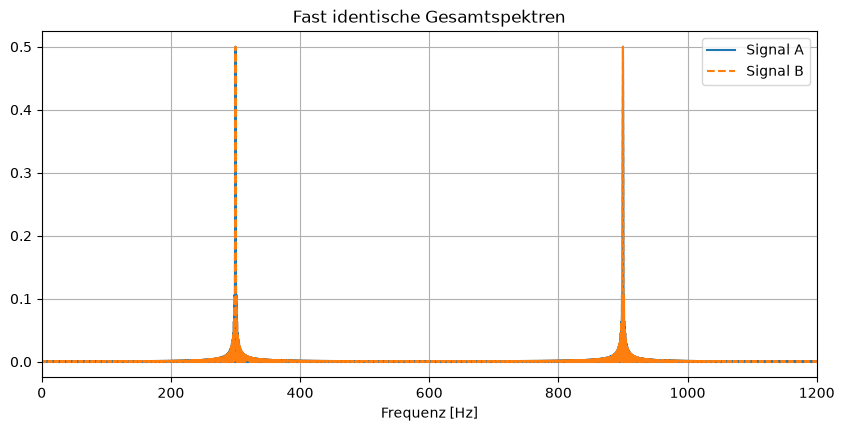

In [9]:
t_demo = np.arange(0, 2.0, 1/FS)

x_a = np.zeros_like(t_demo)
x_a[t_demo < 1.0] = np.sin(2*np.pi*300*t_demo[t_demo < 1.0])
x_a[t_demo >= 1.0] = np.sin(2*np.pi*900*t_demo[t_demo >= 1.0])

x_b = np.zeros_like(t_demo)
x_b[t_demo < 1.0] = np.sin(2*np.pi*900*t_demo[t_demo < 1.0])
x_b[t_demo >= 1.0] = np.sin(2*np.pi*300*t_demo[t_demo >= 1.0])

f_demo = np.fft.rfftfreq(len(t_demo), d=1/FS)
A = 2*np.abs(np.fft.rfft(x_a))/len(x_a)
B = 2*np.abs(np.fft.rfft(x_b))/len(x_b)

fig, ax = plt.subplots()
ax.plot(f_demo, A, label="Signal A")
ax.plot(f_demo, B, "--", label="Signal B")
ax.set_xlim(0, 1200)
ax.set_title("Fast identische Gesamtspektren")
ax.set_xlabel("Frequenz [Hz]")
ax.legend()
plt.show()

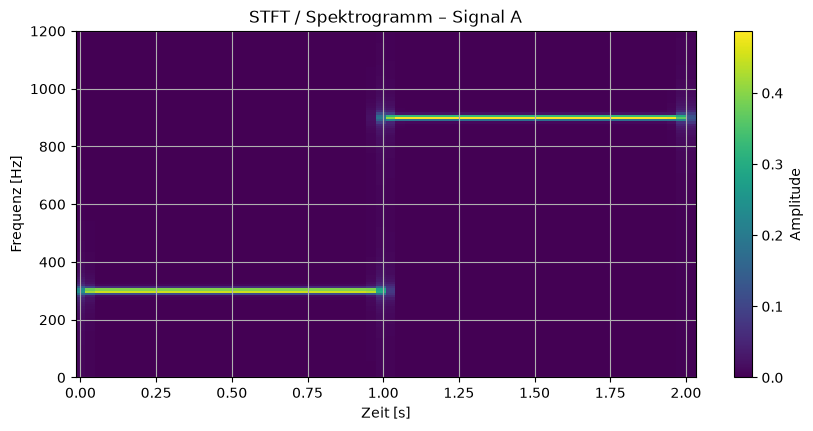

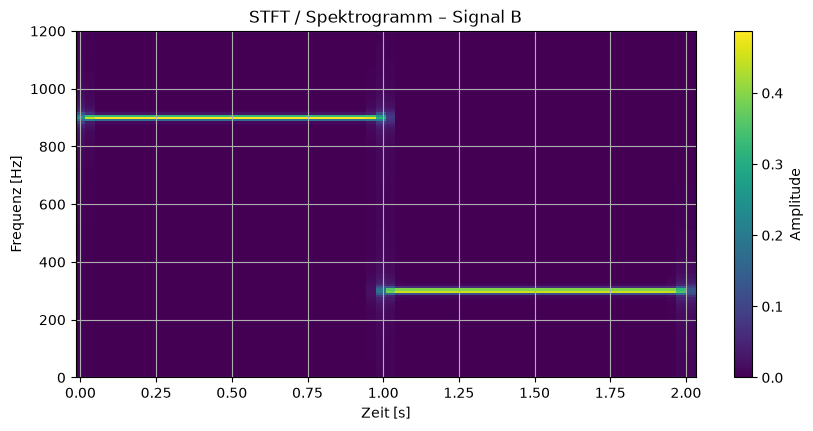

In [10]:
def show_spectrogram(x, title, nperseg=512):
    f, tt, Z = signal.stft(x, fs=FS, window="hann",
                           nperseg=nperseg, noverlap=3*nperseg//4)
    fig, ax = plt.subplots()
    im = ax.pcolormesh(tt, f, np.abs(Z), shading="auto")
    ax.set_ylim(0, 1200)
    ax.set_title(title)
    ax.set_xlabel("Zeit [s]")
    ax.set_ylabel("Frequenz [Hz]")
    fig.colorbar(im, ax=ax, label="Amplitude")
    plt.show()

show_spectrogram(x_a, "STFT / Spektrogramm – Signal A")
show_spectrogram(x_b, "STFT / Spektrogramm – Signal B")

**Trade-off:**  
Kurzes Fenster → gute Zeitauflösung, schlechtere Frequenzauflösung.  
Langes Fenster → gute Frequenzauflösung, schlechtere Zeitauflösung.

## 4. Spektren verdichten: interpretierbare Merkmale

In [11]:
def spectrum_from_signal(x, fs=FS):
    f = np.fft.rfftfreq(len(x), d=1/fs)
    X = np.fft.rfft(x)
    amp = 2*np.abs(X)/len(x)
    power = amp**2
    return f, amp, power

def band_power(freqs, power, lo, hi):
    m = (freqs >= lo) & (freqs < hi)
    return power[m].sum()

def spectral_centroid(freqs, weights):
    w = np.clip(weights, 0, None)
    return np.sum(freqs*w) / (np.sum(w) + 1e-12)

def spectral_spread(freqs, weights):
    c = spectral_centroid(freqs, weights)
    w = np.clip(weights, 0, None)
    return np.sqrt(np.sum(((freqs-c)**2)*w) / (np.sum(w) + 1e-12))

def spectral_entropy(weights):
    w = np.clip(weights, 0, None)
    p = w / (np.sum(w) + 1e-12)
    p = p[p > 0]
    return -np.sum(p*np.log(p))

bands = [(0,250), (250,500), (500,800), (800,1200), (1200,2000)]

def extract_features(x):
    f, amp, power = spectrum_from_signal(x)
    total = power.sum() + 1e-12
    out = {}

    for lo, hi in bands:
        bp = band_power(f, power, lo, hi)
        out[f"band_{lo}_{hi}"] = bp
        out[f"bandrel_{lo}_{hi}"] = bp / total

    out["centroid"] = spectral_centroid(f, power)
    out["spread"] = spectral_spread(f, power)
    out["entropy"] = spectral_entropy(power)

    mask = f >= 20
    idx = np.argmax(amp[mask])
    out["peak_freq"] = f[mask][idx]
    out["peak_amp"] = amp[mask][idx]

    out["rms_time"] = np.sqrt(np.mean(x**2))
    out["peak_time"] = np.max(np.abs(x))
    out["peak_rms_ratio"] = out["peak_time"] / (out["rms_time"] + 1e-12)

    return out

### Bedeutung der Merkmale

- **Bandenergie:** Wie viel Energie liegt in einem interessanten Frequenzbereich?
- **Centroid:** Wo liegt der spektrale Schwerpunkt?
- **Spread:** Wie breit ist die Energie verteilt?
- **Entropie:** Wenige dominante Frequenzen oder breit verteilte Energie?
- **Peak-Merkmale:** Wo liegt die stärkste Schwingung?
- **Peak/RMS-Verhältnis:** Wie impulsiv ist die Messung?

## 5. Feature-Tabelle für alle Einzelmessungen

In [12]:
rows = []
for r in meta.itertuples(index=False):
    feat = extract_features(signals[(r.part_id, r.measurement)])
    rows.append({
        "part_id": r.part_id,
        "measurement": r.measurement,
        "condition": r.condition,
        "rpm": r.rpm,
        **feat
    })

features = pd.DataFrame(rows)
features.head()

,part_id,measurement,condition,rpm,band_0_250,bandrel_0_250,band_250_500,bandrel_250_500,band_500_800,bandrel_500_800,...,band_1200_2000,bandrel_1200_2000,centroid,spread,entropy,peak_freq,peak_amp,rms_time,peak_time,peak_rms_ratio
0,1,0,normal,1821.330196,0.723208,0.570244,0.347114,0.273697,0.141676,0.111710,...,0.036081,0.028449,307.868694,311.519973,2.057945,118.0,0.833912,0.796308,2.237193,2.809457
1,1,1,normal,1821.330196,1.317297,0.677697,0.438741,0.225715,0.128300,0.066005,...,0.039489,0.020315,253.615577,270.206414,2.190677,121.0,1.004097,0.985828,2.584345,2.621498
2,1,2,normal,1821.330196,1.122774,0.665760,0.397879,0.235926,0.106836,0.063350,...,0.037741,0.022379,258.154605,278.351366,2.775346,118.0,0.726900,0.918250,2.489141,2.710745
3,1,3,normal,1821.330196,1.140685,0.619886,0.477089,0.259266,0.164735,0.089522,...,0.038201,0.020759,274.137119,279.907078,2.785929,118.0,0.759471,0.959203,2.615941,2.727203
4,1,4,normal,1821.330196,0.764522,0.539070,0.477123,0.336423,0.118843,0.083797,...,0.039312,0.027719,303.329963,295.386706,2.341245,122.0,0.799444,0.841983,2.204268,2.617950


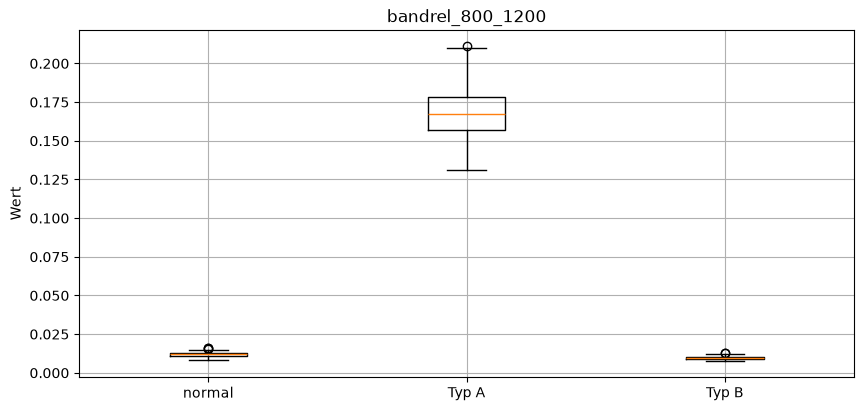

In [13]:
feature_to_show = "bandrel_800_1200"

groups = ["normal", "Typ A", "Typ B"]
vals = [features.loc[features["condition"] == g, feature_to_show] for g in groups]

fig, ax = plt.subplots()
ax.boxplot(vals, tick_labels=groups)
ax.set_title(feature_to_show)
ax.set_ylabel("Wert")
plt.show()

### Mini-Aufgabe
Probiert andere Merkmale:
- `centroid`
- `entropy`
- `peak_freq`
- `peak_rms_ratio`
- `bandrel_250_500`
- `bandrel_800_1200`

**Frage:** Welches Merkmal reagiert besonders auf Typ A? Welches eher auf Typ B?

## 6. Viele Messungen pro Bauteil → eine Zeile pro Bauteil

In [14]:
feature_cols = [c for c in features.columns
                if c not in ["part_id", "measurement", "condition", "rpm"]]

agg_map = {}
for c in feature_cols:
    agg_map[c] = ["mean", "std", "max"]

agg = features.groupby(["part_id", "condition"]).agg(agg_map)
agg.columns = [f"{a}_{b}" for a, b in agg.columns]
agg = agg.reset_index()

agg.head()

,part_id,condition,band_0_250_mean,band_0_250_std,band_0_250_max,bandrel_0_250_mean,bandrel_0_250_std,bandrel_0_250_max,band_250_500_mean,band_250_500_std,...,peak_amp_max,rms_time_mean,rms_time_std,rms_time_max,peak_time_mean,peak_time_std,peak_time_max,peak_rms_ratio_mean,peak_rms_ratio_std,peak_rms_ratio_max
0,1,normal,1.035058,0.200241,1.317297,0.620662,0.043376,0.679146,0.423619,0.081620,...,1.121334,0.908492,0.069551,1.006560,2.409599,0.169926,2.615941,2.654876,0.092133,2.809457
1,2,normal,1.006946,0.191940,1.388138,0.612090,0.047869,0.693779,0.436538,0.071631,...,1.064413,0.902583,0.059223,1.000179,2.511698,0.191449,2.953277,2.785931,0.171945,3.061087
2,3,normal,0.991671,0.108051,1.110573,0.629682,0.043618,0.687595,0.383522,0.037372,...,1.032071,0.886219,0.032612,0.934292,2.334751,0.129758,2.512802,2.634052,0.098146,2.794278
3,4,normal,1.032312,0.150254,1.314880,0.614918,0.050205,0.684874,0.427713,0.067773,...,1.003551,0.914000,0.044880,0.983445,2.448289,0.161999,2.804256,2.679092,0.125442,2.851462
4,5,normal,1.012910,0.116530,1.224345,0.622374,0.053655,0.703603,0.415848,0.091340,...,1.035918,0.901507,0.036786,0.945366,2.411493,0.159147,2.789885,2.673915,0.111469,2.951118


So verdichten wir in zwei Stufen:

\[
	ext{Zeitreihe}

ightarrow
	ext{Spektrum}

ightarrow
	ext{Merkmale je Messung}

ightarrow
	ext{Merkmale je Bauteil}
\]

Das ist oft schon ausreichend, um aus vielen Rohdaten eine handhabbare Tabelle zu machen.

## 7. Feature-Heatmap

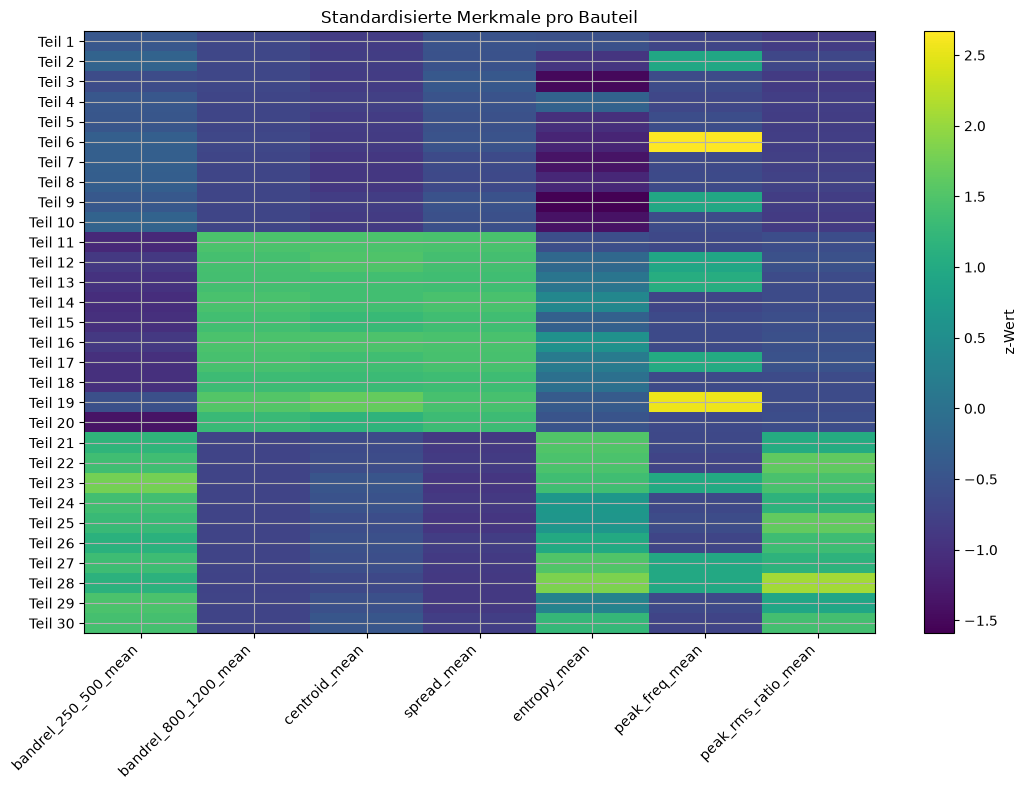

In [15]:
heat_features = [
    "bandrel_250_500_mean",
    "bandrel_800_1200_mean",
    "centroid_mean",
    "spread_mean",
    "entropy_mean",
    "peak_freq_mean",
    "peak_rms_ratio_mean"
]

Xz = StandardScaler().fit_transform(agg[heat_features])

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(Xz, aspect="auto")
ax.set_xticks(np.arange(len(heat_features)))
ax.set_xticklabels(heat_features, rotation=45, ha="right")
ax.set_yticks(np.arange(len(agg)))
ax.set_yticklabels([f"Teil {p}" for p in agg["part_id"]])
ax.set_title("Standardisierte Merkmale pro Bauteil")
fig.colorbar(im, ax=ax, label="z-Wert")
plt.tight_layout()
plt.show()

## 8. Gesamte Spektrumsform vergleichen: Wasserstein-Distanz

In [16]:
all_spectra = []
for r in meta.itertuples(index=False):
    f, amp, power = spectrum_from_signal(signals[(r.part_id, r.measurement)])
    p = power / (power.sum() + 1e-12)
    all_spectra.append(p)

all_spectra = np.vstack(all_spectra)

# Unsupervised Referenz: Median über alle Spektren
reference = np.median(all_spectra, axis=0)
reference = reference / reference.sum()

w_dist = [
    wasserstein_distance(f, f, u_weights=p, v_weights=reference)
    for p in all_spectra
]

dist_df = meta.copy()
dist_df["wasserstein"] = w_dist
dist_df.head()

,part_id,measurement,condition,rpm,wasserstein
0,1,0,normal,1821.330196,149.832449
1,1,1,normal,1821.330196,204.776563
2,1,2,normal,1821.330196,198.801758
3,1,3,normal,1821.330196,182.646597
4,1,4,normal,1821.330196,160.173362


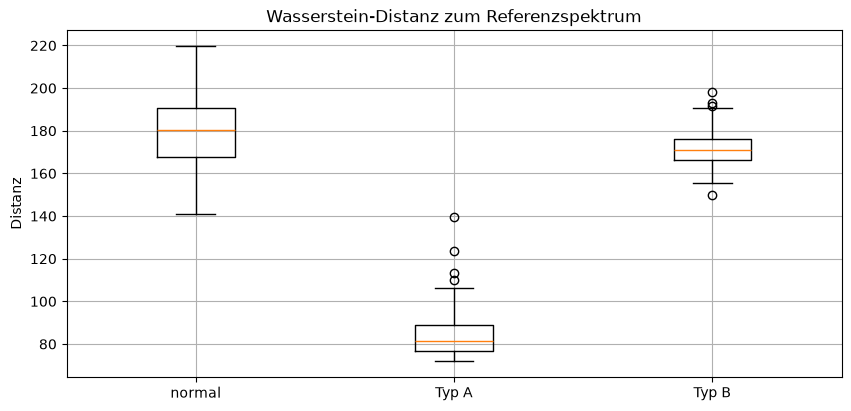

In [17]:
groups = ["normal", "Typ A", "Typ B"]
vals = [dist_df.loc[dist_df["condition"] == g, "wasserstein"] for g in groups]

fig, ax = plt.subplots()
ax.boxplot(vals, tick_labels=groups)
ax.set_title("Wasserstein-Distanz zum Referenzspektrum")
ax.set_ylabel("Distanz")
plt.show()

**Wichtig:** Große Distanz bedeutet zunächst nur **ungewöhnlich im Vergleich zur Referenz**.  
Sie bedeutet nicht automatisch **defekt**.

## 9. Anomalie-Score pro Bauteil

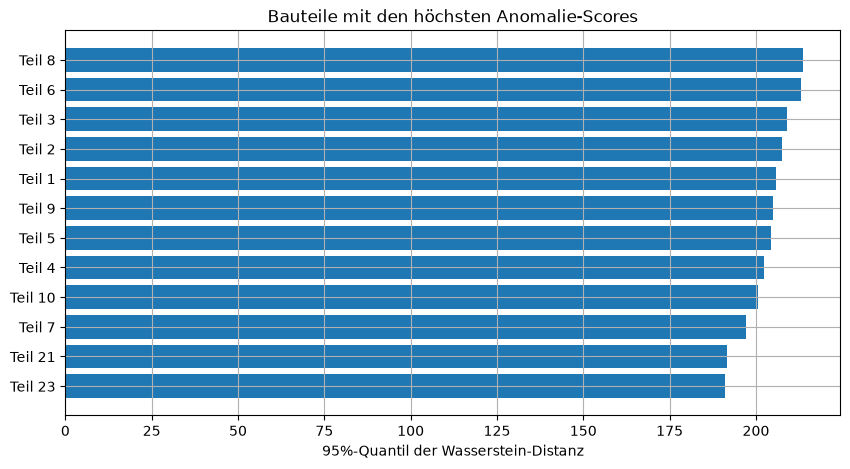

,part_id,condition,wasserstein_q95
22,23,Typ B,190.928362
20,21,Typ B,191.481851
6,7,normal,197.178428
9,10,normal,200.523302
3,4,normal,202.392959
4,5,normal,204.426321
8,9,normal,204.831289
0,1,normal,205.675825
1,2,normal,207.456879
2,3,normal,209.080618


In [18]:
part_dist = dist_df.groupby(["part_id", "condition"])["wasserstein"].agg(
    wasserstein_mean="mean",
    wasserstein_max="max",
    wasserstein_q95=lambda x: np.quantile(x, 0.95)
).reset_index()

part_dist = part_dist.sort_values("wasserstein_q95", ascending=False)

top = part_dist.head(12).sort_values("wasserstein_q95")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([f"Teil {p}" for p in top["part_id"]], top["wasserstein_q95"])
ax.set_title("Bauteile mit den höchsten Anomalie-Scores")
ax.set_xlabel("95%-Quantil der Wasserstein-Distanz")
plt.show()

top[["part_id", "condition", "wasserstein_q95"]]

## 10. Spektrale Entwicklung eines Bauteils

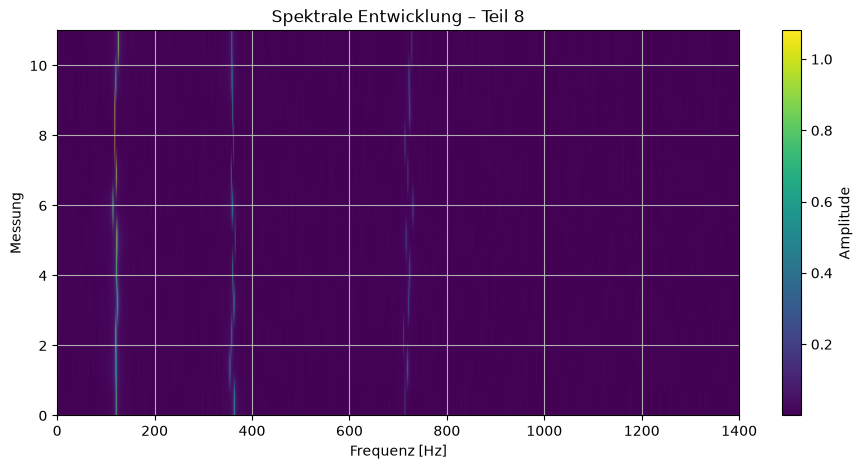

Eingebaute Klasse: normal


In [19]:
PART_TO_INSPECT = int(part_dist.iloc[0]["part_id"])

def spectral_map(part_id, f_max=1400):
    rows_part = meta[meta["part_id"] == part_id].sort_values("measurement")
    spectra = []

    for r in rows_part.itertuples(index=False):
        f, amp, _ = spectrum_from_signal(signals[(r.part_id, r.measurement)])
        spectra.append(amp)

    spectra = np.vstack(spectra)
    mask = f <= f_max

    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(
        spectra[:, mask],
        aspect="auto",
        origin="lower",
        extent=[f[mask][0], f[mask][-1], 0, spectra.shape[0]-1]
    )
    ax.set_title(f"Spektrale Entwicklung – Teil {part_id}")
    ax.set_xlabel("Frequenz [Hz]")
    ax.set_ylabel("Messung")
    fig.colorbar(im, ax=ax, label="Amplitude")
    plt.show()

spectral_map(PART_TO_INSPECT)
print("Eingebaute Klasse:", meta.loc[meta["part_id"] == PART_TO_INSPECT, "condition"].iloc[0])

> Diese Darstellung ähnelt einem Spektrogramm, ist aber **keine STFT**, solange die einzelnen Spektren nicht aus überlappenden Fenstern desselben kontinuierlichen Signals stammen.

## 11. Optional: Clustering auf den extrahierten Merkmalen

In [20]:
cluster_features = [
    "bandrel_250_500_mean",
    "bandrel_800_1200_mean",
    "centroid_mean",
    "spread_mean",
    "entropy_mean",
    "peak_rms_ratio_mean"
]

X = StandardScaler().fit_transform(agg[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
agg["cluster"] = kmeans.fit_predict(X)

pd.crosstab(agg["condition"], agg["cluster"])

cluster,0,1,2
condition,,,
Typ A,10,0,0
Typ B,0,10,0
normal,0,0,10


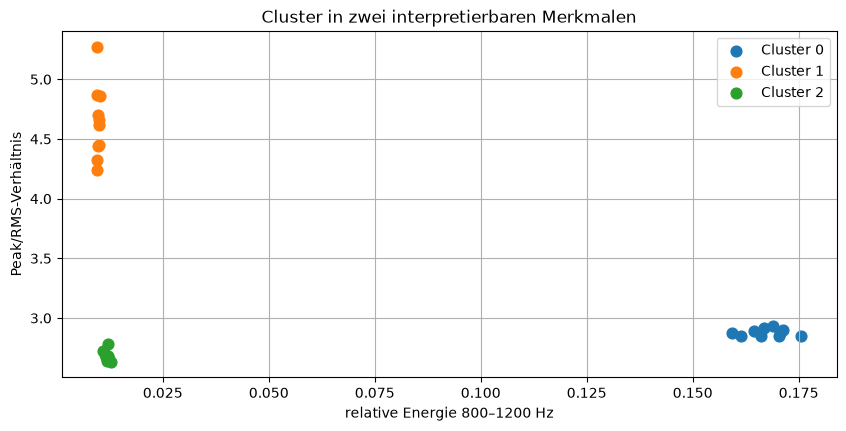

In [21]:
fig, ax = plt.subplots()
for cl in sorted(agg["cluster"].unique()):
    m = agg["cluster"] == cl
    ax.scatter(
        agg.loc[m, "bandrel_800_1200_mean"],
        agg.loc[m, "peak_rms_ratio_mean"],
        s=60,
        label=f"Cluster {cl}"
    )

ax.set_xlabel("relative Energie 800–1200 Hz")
ax.set_ylabel("Peak/RMS-Verhältnis")
ax.set_title("Cluster in zwei interpretierbaren Merkmalen")
ax.legend()
plt.show()

Ein Cluster bedeutet nur: **Diese Bauteile sehen sich in den ausgewählten Merkmalen ähnlich.**

Erst mit Prozess- oder Qualitätswissen lässt sich beurteilen, ob ein Cluster fachlich relevant ist.

## 12. Bonus: Drehzahl-Normalisierung / Ordnungsanalyse

In [22]:
example_rpm = 1800
f_rot = example_rpm / 60

print(f"Rotationsfrequenz bei {example_rpm} rpm: {f_rot:.1f} Hz")

for f_peak in [120, 360, 720]:
    print(f"{f_peak:4.0f} Hz -> Ordnung {f_peak/f_rot:.1f}")

Rotationsfrequenz bei 1800 rpm: 30.0 Hz
 120 Hz -> Ordnung 4.0
 360 Hz -> Ordnung 12.0
 720 Hz -> Ordnung 24.0


Die Ordnung ist

\[
o = \frac{f}{f_\mathrm{rot}}
\]

und kann Frequenzvergleiche bei leicht wechselnder Drehzahl robuster machen.

# Zusammenfassung

Wir haben folgende Pipeline aufgebaut:

\[
	ext{Zeitreihe}

ightarrow
	ext{FFT / STFT}

ightarrow
	ext{Spektrale Merkmale}

ightarrow
	ext{Aggregation pro Bauteil}

ightarrow
	ext{Vergleich / Anomalie / Cluster}
\]

## Take-aways

1. **Nicht jede Analyse braucht Machine Learning.**  
   Physikalisch interpretierbare Merkmale machen große Datenmengen oft schon sehr gut überschaubar.

2. **Vergleichbarkeit kommt vor dem Algorithmus.**  
   Nur Messungen unter vergleichbaren Bedingungen sollten direkt miteinander verglichen werden.

3. **Ein Anomalie-Score ist noch keine Fehlerdiagnose.**  
   Er identifiziert Kandidaten für eine nähere Untersuchung.

4. **Domänenwissen ist ein Vorteil.**  
   Sinnvolle Frequenzbänder, Drehzahl, Maschinenzustand und bekannte Resonanzen sind oft wertvoller als rein datengetriebene Reduktion.